In [2]:
!pip install pytesseract
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn

# LIBRARY

In [1]:
import os
import re
import string
import pickle
import glob
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

from sklearn.model_selection import train_test_split
from sklearn.model_selection import learning_curve
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix


# EXPLORASI DAN VISUALISASI DATA

## Pemanggilan Dataset

In [2]:
folder_path = r"F:\tubes\hoaxbuster\Dataset_Cleaned"

all_files = glob.glob(os.path.join(folder_path, "*.csv"))

list = [pd.read_csv(f) for f in all_files]
dg = pd.concat(list, ignore_index=True)

print(f"Total data dari {len(all_files)} file: {len(dg)}")
print(dg.head())

Total data dari 4 file: 23944
                                                 url  \
0  https://www.antaranews.com/berita/5272973/angg...   
1  https://www.antaranews.com/berita/5271789/bskd...   
2  https://www.antaranews.com/berita/5271561/sesk...   
3  https://www.antaranews.com/berita/5271817/ekon...   
4  https://www.antaranews.com/berita/5272929/wame...   

                                               judul  \
0  Anggota DPR minta polisi ungkap dalang perusak...   
1  BSKDN: Kepentingan umum harus jadi orientasi u...   
2  Seskab: Prabowo minta respons cepat dan bantua...   
3  Ekonom Golkar nilai kebijakan PLTS satu desa s...   
4  Wamendagri: Bangun layanan publik sesuai kebut...   

                                              narasi  label  \
0  Jakarta (ANTARA) - Anggota Komisi IV DPR RI Ra...      0   
1  Jakarta (ANTARA) - Badan Strategi Kebijakan Da...      0   
2  Jakarta (ANTARA) - Sekretaris Kabinet (Seskab)...      0   
3  Jakarta (ANTARA) - Ekonom Partai Golkar A

## Sebaran Data

C:\Users\mocha\AppData\Local\Temp\ipykernel_17496\4066014852.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=dg, palette='magma')


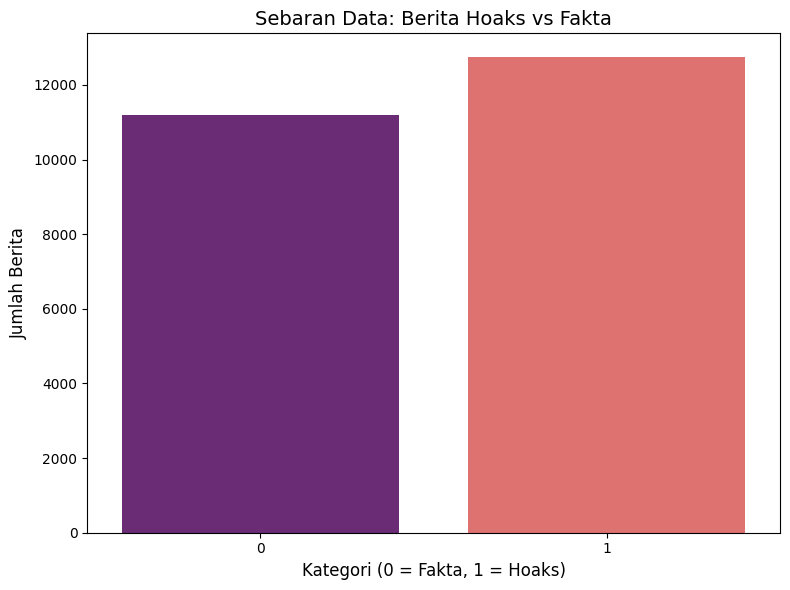

In [3]:
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=dg, palette='magma')
plt.title('Sebaran Data: Berita Hoaks vs Fakta', fontsize=14)
plt.xlabel('Kategori (0 = Fakta, 1 = Hoaks)', fontsize=12)
plt.ylabel('Jumlah Berita', fontsize=12)

plt.tight_layout()
plt.show()

# Pra-Proses Data

## Pembersihan Teks

In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\n', ' ', text)
    return text

dg['clean_text'] = dg['narasi'].apply(clean_text)

data = dg.drop(columns=['url', 'narasi'])

print(data[['clean_text', 'label']].head())

                                          clean_text  label
0  jakarta antara  anggota komisi iv dpr ri rajiv...      0
1  jakarta antara  badan strategi kebijakan dalam...      0
2  jakarta antara  sekretaris kabinet seskab tedd...      0
3  jakarta antara  ekonom partai golkar abdul rah...      0
4  jakarta antara  wakil menteri dalam negeri wam...      0


## TF-IDF

In [5]:
max_words = 10000 

vectorizer = TfidfVectorizer(max_features=max_words)

X = vectorizer.fit_transform(data['clean_text']).toarray()
y = data['label'].values

print(X.shape)
print(y.shape)

(23944, 10000)
(23944,)


In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print({len(X_train)}, {len(X_val)}, {len(X_test)})

(19155, 10000)
{19155} {2394} {2395}


# Model Training

### SVM

In [7]:
model = SVC(kernel='linear', C=1.0, random_state=42)

model.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'linear',
 'max_iter': -1,
 'probability': False,
 'random_state': 42,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [8]:
start_time = time.time()

model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [11]:
y_pred = model.predict(X_val)

val_acc = accuracy_score(y_val, y_pred)
val_f1 = f1_score(y_val, y_pred, average='weighted')

print(f"{'VAL ACCURACY':<15} : {val_acc:.4f}")
print(f"{'F1 SCORE':<15} : {val_f1:.4f}")

VAL ACCURACY    : 0.9854
F1 SCORE        : 0.9854


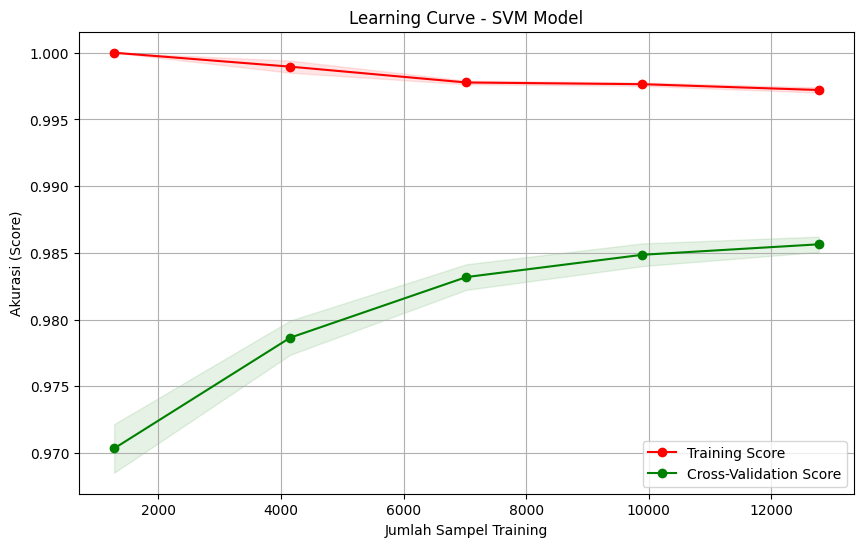

In [12]:
plt.figure(figsize=(10, 6))

train_sizes, train_scores, test_scores = learning_curve(
    model, X_train, y_train, 
    cv=3,
    scoring='accuracy', 
    n_jobs=1,
    train_sizes=np.linspace(0.1, 1.0, 5) 
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training Score")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")

plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-Validation Score")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

plt.title('Learning Curve - SVM Model')
plt.xlabel('Jumlah Sampel Training')
plt.ylabel('Akurasi (Score)')
plt.legend(loc="best")
plt.grid(True)

plt.show()

# EVALUASI

              precision    recall  f1-score   support

       Fakta       0.98      0.99      0.98      1124
       Hoaks       0.99      0.98      0.99      1271

    accuracy                           0.98      2395
   macro avg       0.98      0.99      0.98      2395
weighted avg       0.98      0.98      0.98      2395



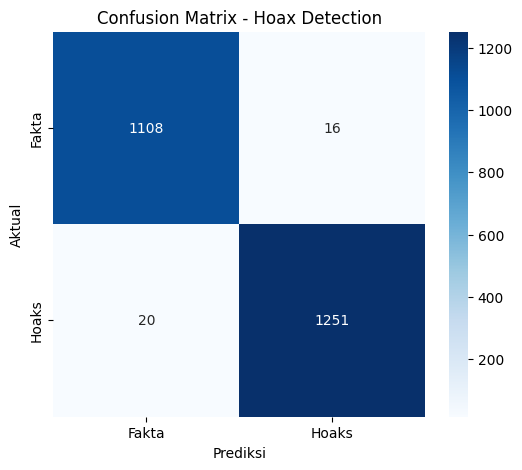

In [9]:
y_pred_test = model.predict(X_test)
print(classification_report(y_test, y_pred_test, target_names=['Fakta', 'Hoaks']))

cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fakta', 'Hoaks'],
            yticklabels=['Fakta', 'Hoaks'])

plt.title('Confusion Matrix - Hoax Detection')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# SIMPAN MODEL

In [10]:
model_filename = 'model_hoax_svm.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(model, file)

vectorizer_filename = 'tfidf_vectorizer.pkl'
with open(vectorizer_filename, 'wb') as file:
    pickle.dump(vectorizer, file)

# REAL-TEST

In [ ]:
def check_hoax(teks_baru):
    teks_bersih = clean_text(teks_baru)
    vec = vectorizer.transform([teks_bersih]).toarray()
    pred_label = model.predict(vec)[0]
    if pred_label == 1:
        label = "HOAKS"
    else:
        label = "FAKTA"

    print(f"\nKalimat: '{teks_baru}'")
    print(f"Hasil  : {label}")

check_hoax("Pemerintah resmi membagikan subsidi listrik dan kuota internet gratis 100GB untuk seluruh rakyat mulai hari ini. Segera cek nama anda dan klaim melalui link berikut: http://subsidi-pemerintah.xyz. Jangan lupa sebarkan ke grup wa keluarga agar semua kebagian.")


Kalimat: 'Pemerintah resmi membagikan subsidi listrik dan kuota internet gratis 100GB untuk seluruh rakyat mulai hari ini. Segera cek nama anda dan klaim melalui link berikut: http://subsidi-pemerintah.xyz. Jangan lupa sebarkan ke grup wa keluarga agar semua kebagian.'
Hasil  : HOAKS
